<a href="https://colab.research.google.com/github/unnati-mangal/data-analytics-module-4/blob/main/module__4_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name - Unnati Mangal


Roll No. - BETN1AI25053

In [ ]:
# TASK 1 - Handling Missing Values
print("Handling Missing Values\n")
import pandas as pd
import numpy as np

data = {'Age': [25, np.nan, 30, 35, np.nan],
    'Salary': [50000, 60000, np.nan, 80000, 75000]}

df = pd.DataFrame(data)

print(df.isnull())

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

print(df)

Handling Missing Values

     Age  Salary
0  False   False
1   True   False
2  False    True
3  False   False
4   True   False
    Age   Salary
0  25.0  50000.0
1  30.0  60000.0
2  30.0  66250.0
3  35.0  80000.0
4  30.0  75000.0


Outlier Detection & Treatment



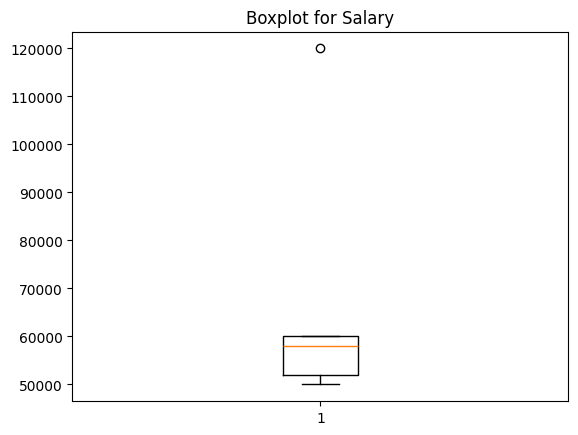

   Salary
0   50000
1   52000
2   58000
3   60000


In [ ]:
# TASK 2 - Outlier Detection & Treatment
print("Outlier Detection & Treatment\n")
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Salary': [50000, 52000, 58000, 60000, 120000]
})

plt.boxplot(df['Salary'])
plt.title("Boxplot for Salary")
plt.show()

Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['Salary'] >= lower) & (df['Salary'] <= upper)]

print(df_clean)

In [ ]:
# Task 3 - Data Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

print(scaled_data)

[[-1.21267813]
 [-0.72760688]
 [ 0.72760688]
 [ 1.21267813]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
data = {
    'Age': [25, 30, 35, 40, 45],
    'Salary': [50000, 60000, 70000, 80000, 90000]
}

X = pd.DataFrame(data)

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print("Original Data:\n", X)
print("\nTraining Data:\n", X_train)
print("\nTest Data:\n", X_test)
print("\nScaled Training Data:\n", X_train_scaled)
print("\nScaled Test Data:\n", X_test_scaled)

Original Data:
    Age  Salary
0   25   50000
1   30   60000
2   35   70000
3   40   80000
4   45   90000

Training Data:
    Age  Salary
4   45   90000
2   35   70000
0   25   50000
3   40   80000

Test Data:
    Age  Salary
1   30   60000

Scaled Training Data:
 [[ 1.18321596  1.18321596]
 [-0.16903085 -0.16903085]
 [-1.52127766 -1.52127766]
 [ 0.50709255  0.50709255]]

Scaled Test Data:
 [[-0.84515425 -0.84515425]]


In [ ]:
# Mini Case Study
print("Mini Case Study\n")
data = {'Age': [22, 25, 47, 52, 46],
    'Income': [15000, 18000, 65000, 72000, 69000]}

df = pd.DataFrame(data)

# Normalize income
df['Income_norm'] = (df['Income'] - df['Income'].min()) / (df['Income'].max() - df['Income'].min())

print(df)

# detect any anomalies
df['z_score'] = (df['Income'] - df['Income'].mean()) / df['Income'].std()

print(df)

Mini Case Study

   Age  Income  Income_norm
0   22   15000     0.000000
1   25   18000     0.052632
2   47   65000     0.877193
3   52   72000     1.000000
4   46   69000     0.947368
   Age  Income  Income_norm   z_score
0   22   15000     0.000000 -1.142850
1   25   18000     0.052632 -1.038321
2   47   65000     0.877193  0.599299
3   52   72000     1.000000  0.843200
4   46   69000     0.947368  0.738671


Interpretation:
1. Income values (65000–72000) are significantly higher
2. May represent a different income group
3. No extreme outlier but clear data variation
4. Normalization scales values between 0–1